# 82 - Milestone Project: Psychometric Functions in CNNs

**Section:** CNN Milestone Projects | **Prereqs:** `CNN Milestone Projects/CIFAR_10_AutoEncoder.ipynb` | **Next:** `Transfer Learning/TF_MNIST-_FMNIST.ipynb`

The most interesting experiment in the repository, and it is about *probing* a
model rather than training one.

**Setup.** Train a CNN on an easy binary task - is the bar in this noisy image
horizontal or vertical? Then test it on something it never saw: clean lines at
every slope from steep to shallow, and plot P(vertical) against slope.

**That plot is a psychometric function**, borrowed straight from experimental
psychology, where the same curve is measured on human observers. It reveals
things accuracy cannot:
- Where is the model's decision boundary - at 45 degrees, as it should be, or
  biased?
- How *sharp* is the transition? A steep curve means confident, near-categorical
  decisions; a shallow one means graded uncertainty.
- Does it generalise from noisy thick bars to clean thin lines at all?

**The method generalises.** Train on your real data, test on a controlled
continuum you construct, and plot the response as a function of the parameter you
varied. It is how you find out what a model is actually keying on - much more
informative than another accuracy number, and it is the same family of technique
as `CNNs/Examining_Feature_Maps.ipynb`.

**One caveat about the data:** the label is set to 1 only inside the `else`
branch, so 'vertical' and 'the label is 1' are correct, but every horizontal image
relies on the array being pre-zeroed. It works, and it is worth reading carefully
before copying.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from torchsummary import summary


In [20]:
# The training data: Gaussian noise plus one bright bar, horizontal or vertical,
# at a random position and thickness.
# Note labels[i] is only assigned inside the `else` (vertical) branch - the
# horizontal case relies on the tensor having been pre-zeroed. Correct, but
# fragile to read.
nImages = 2000
imgSize = 30

device = ('cuda' if torch.cuda.is_available() else 'cpu')

images = torch.zeros(nImages,1,imgSize,imgSize)
labels = torch.zeros(nImages,1)

for i in range(nImages):

  G  = np.random.randn(imgSize,imgSize)

  # add a random bar randomly
  i1 = np.random.choice(np.arange(2,28))
  i2 = np.random.choice(np.arange(2,6))
  if np.random.randn()>0:
    G[i1:i1+i2,] = 1 # horizontal
  else:
    G[:,i1:i1+i2] = 1 # vertical
    labels[i] = 1

  # add to the tensor
  images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize).to(device).float()

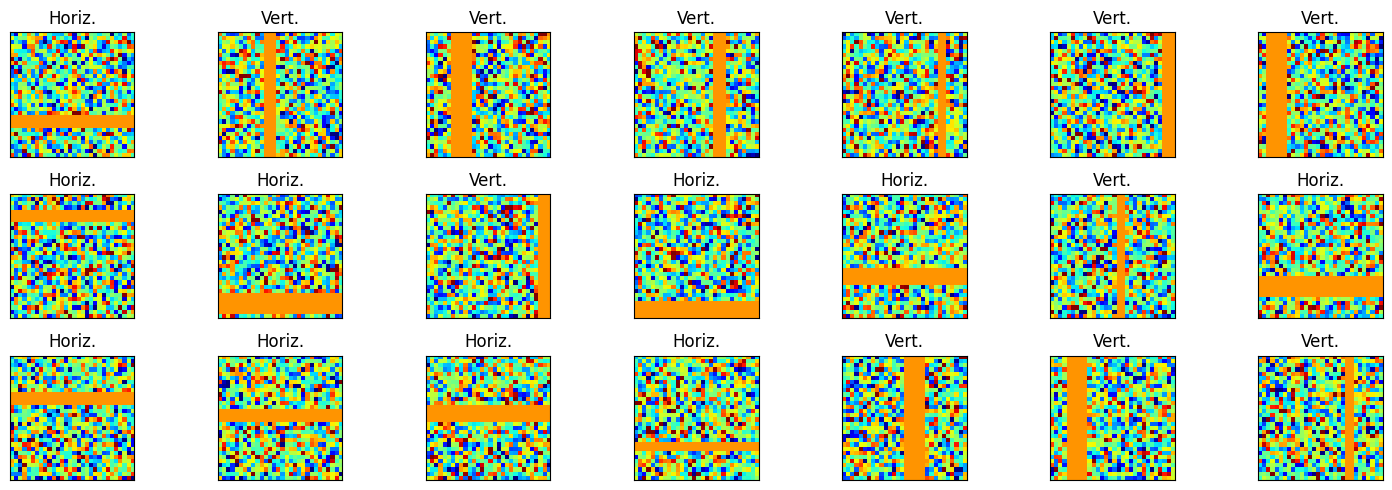

In [21]:
# Sample images. The bar is clear despite the noise - the task is easy by design,
# because the interesting part is the probe, not the training.
fig,axs = plt.subplots(3,7,figsize=(15,5))

for i,ax in enumerate(axs.flatten()):
  whichpic = np.random.randint(nImages)
  G = np.squeeze( images[whichpic,:,:] )
  ax.imshow(G,vmin=-2,vmax=2,cmap='jet',extent=[-4,4,-4,4],origin='upper')

  title = 'Horiz.' if labels[whichpic].item()==0 else 'Vert.'
  ax.set_title(title)
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()


In [22]:
images.shape, labels.shape

(torch.Size([2000, 1, 30, 30]), torch.Size([2000, 1]))

In [23]:
# Split and loaders. Labels are float (N,1) for BCEWithLogitsLoss.
device = ('cuda' if torch.cuda.is_available() else 'cpu')

X_train, X_test, Y_train, Y_test = train_test_split(images,labels,test_size=0.2)

# Ensure all split tensors are on the correct device *before* creating the TensorDataset
X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

train_dataset = TensorDataset(X_train, Y_train)
val_datset = TensorDataset(X_test,Y_test)

bs = 32

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(val_datset, batch_size=val_datset.tensors[0].shape[0])

In [24]:
# A small CNN: two [Conv-BN-ReLU-Pool] blocks, then a flatten and a classifier
# ending in a single logit.
class CNNmodel(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.layers = nn.Sequential(
        nn.Conv2d(1,16,3,1,2), # Out -> [8,30,30]
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(2,2), # Out -> [8,15,15]

        nn.Conv2d(16,32,3,2,1), # Out -> [16,8,8]
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2,2), # Out [16,4,4]

        nn.Flatten(),
        nn.Linear(32*4*4, 64),
        nn.Dropout(p=0.5),
        nn.BatchNorm1d(64),
        nn.ReLU(),

        nn.Linear(64,1)
    )


  def forward(self,x):
    return self.layers(x)

In [25]:
# torchsummary.
test_model = CNNmodel().to(device)

summary(test_model, input_size=(1,30,30), batch_size=bs)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 16, 32, 32]             160
       BatchNorm2d-2           [32, 16, 32, 32]              32
              ReLU-3           [32, 16, 32, 32]               0
         MaxPool2d-4           [32, 16, 16, 16]               0
            Conv2d-5             [32, 32, 8, 8]           4,640
       BatchNorm2d-6             [32, 32, 8, 8]              64
              ReLU-7             [32, 32, 8, 8]               0
         MaxPool2d-8             [32, 32, 4, 4]               0
           Flatten-9                  [32, 512]               0
           Linear-10                   [32, 64]          32,832
          Dropout-11                   [32, 64]               0
      BatchNorm1d-12                   [32, 64]             128
             ReLU-13                   [32, 64]               0
           Linear-14                   

In [26]:
# Training with BCEWithLogitsLoss plus L1, weight decay and dropout.
def train_model():

  model = CNNmodel().to(device)

  lossfunc = nn.BCEWithLogitsLoss()
  epochs = 50
  optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=5e-4,
    betas=(0.9, 0.999)
)


  losses = []
  train_acc = []
  val_acc = []

  l1_lambda = 5e-4

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossfunc(yhat,y)

      # Calculate L1 norm and normalize by the number of parameters
      l1_norm = sum(p.abs().sum() for p in model.parameters())
      num_parameters = sum(p.numel() for p in model.parameters())
      loss = loss + l1_lambda * (l1_norm / num_parameters)

      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( ((yhat > 0).float() == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      # Calculate accuracy more explicitly to ensure float type for torch.mean
      predictions = (model(X) > 0).float()
      correct_mask = (predictions == Y)
      accuracy_tensor = correct_mask.float()
      val_acc.append( 100 * torch.mean(accuracy_tensor).detach().cpu())


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

In [27]:
model, losses, train_acc, val_acc = train_model()

Epoch 0 | Loss : 0.6908 | Train Acc 53.9375 | Val Acc : 60.749996185302734
Epoch 10 | Loss : 0.2861 | Train Acc 94.875 | Val Acc : 96.25
Epoch 20 | Loss : 0.1163 | Train Acc 99.25 | Val Acc : 99.75
Epoch 30 | Loss : 0.0556 | Train Acc 99.9375 | Val Acc : 100.0
Epoch 40 | Loss : 0.0359 | Train Acc 99.9375 | Val Acc : 99.75
Epoch 49 | Loss : 0.0231 | Train Acc 100.0 | Val Acc : 99.75


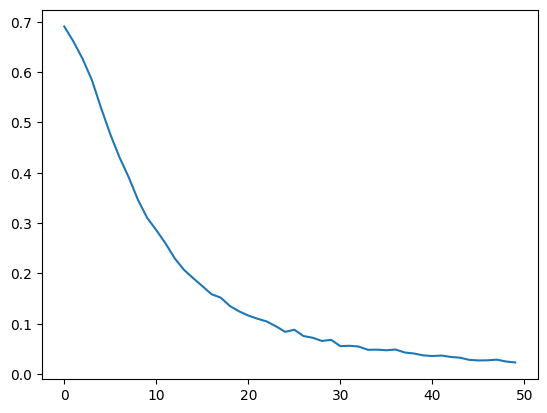

In [28]:
# Loss curve.
plt.plot(losses);

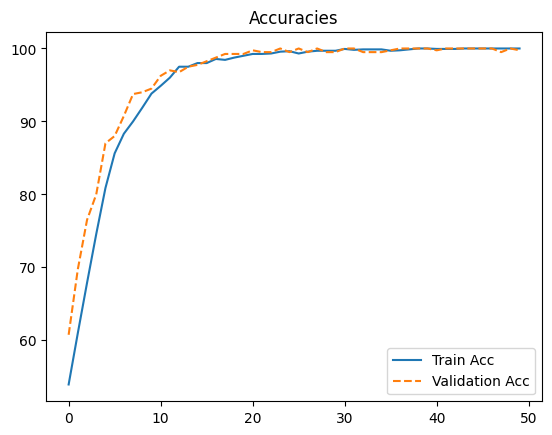

In [29]:
# Train and validation accuracy. This should be near-perfect - the task is easy,
# and the point of the notebook lies in what comes after.
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, '--', label='Validation Acc')
plt.legend()
plt.title("Accuracies");


## Testing

In [30]:
# skimage's line_aa draws anti-aliased lines - clean, thin, and at any slope.
# Nothing like the thick noisy bars the model trained on.
from skimage.draw import line_aa

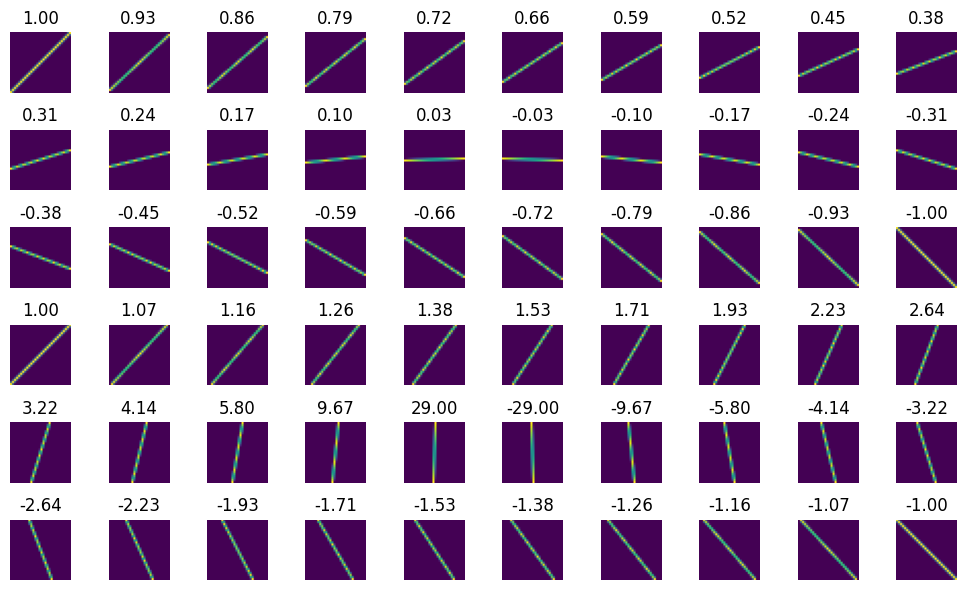

In [31]:
# The probe set: 60 lines spanning slopes from near-horizontal to near-vertical,
# built in two families (|slope| < 1 and |slope| > 1) so the whole range is
# covered evenly.
fig,ax = plt.subplots(6,10,figsize=(10,6))
imgs   = np.zeros((2*imgSize,1,imgSize,imgSize))
slopes = np.zeros(2*imgSize)

a = ax.flatten()
for i in range(imgSize):

  ### create lines with |slope|<1
  # point coords
  p1 = [0,i]
  p2 = [imgSize-p1[0]-1,imgSize-p1[1]-1]
  slopes[i] = (p2[1]-p1[1])/(p2[0]-p1[0]+1e-10)

  # create the lines
  rows,cols,val = line_aa(p1[1],p1[0],p2[1],p2[0]) #  y1,x1,y2,x2
  imgs[i,0,rows,cols] = val

  # plot
  a[i].imshow(imgs[i,0,:,:],origin='lower')
  a[i].set_title('%.2f'%slopes[i])
  a[i].axis('off')


  ### create lines with |slope|>1
  # point coords
  p1 = [i,0]
  p2 = [imgSize-p1[0]-1,imgSize-p1[1]-1]
  slopes[i+imgSize] = (p2[1]-p1[1])/(p2[0]-p1[0]+1e-10)

  # create the lines
  rows,cols,val = line_aa(p1[1],p1[0],p2[1],p2[0]) #  y1,x1,y2,x2
  imgs[i+imgSize,0,rows,cols] = val

  # plot
  a[i+imgSize].imshow(imgs[i+imgSize,0,:,:],origin='lower')
  a[i+imgSize].set_title('%.2f'%slopes[i+imgSize])
  a[i+imgSize].axis('off')

plt.tight_layout()
plt.show()


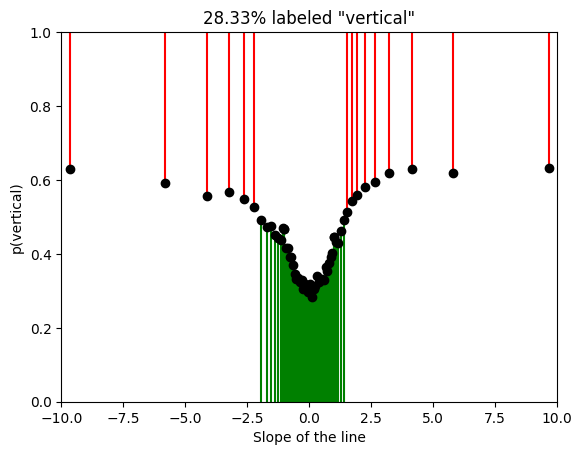

In [32]:
# THE PSYCHOMETRIC FUNCTION: P(vertical) against slope.
# Read it for three things:
#   - where the curve crosses 0.5 (the decision boundary - is it at 45 degrees?),
#   - how STEEP the crossing is (sharp = categorical, shallow = graded),
#   - whether the extremes saturate at 0 and 1 (confident at easy slopes).
# Sigmoid is applied explicitly here because the model outputs logits and this
# plot needs probabilities.
# Note this generalises well outside the training distribution: thick noisy bars
# in, clean thin lines out.
ridx = np.random.permutation(range(imgs.shape[0]))
imgT = torch.tensor(imgs[ridx,:,:,:].astype(np.float32)).to(device)

model.eval()
yHat = torch.sigmoid( model(imgT) ).detach()

for i in range(len(slopes)):
  if yHat[i]>.5:
    plt.plot([slopes[ridx[i]],slopes[ridx[i]]],[1,yHat[i].item()],'r')
  else:
    plt.plot([slopes[ridx[i]],slopes[ridx[i]]],[0,yHat[i].item()],'g')

plt.plot(slopes[ridx],yHat.cpu(),'ko')
plt.xlabel('Slope of the line')
plt.ylabel('p(vertical)')
plt.title('%.2f%% labeled "vertical"' %torch.mean(100*(yHat>.5).float()).item())
plt.ylim([0,1])
plt.xlim([-10,10]) # note: this actually clips two data points
plt.show()

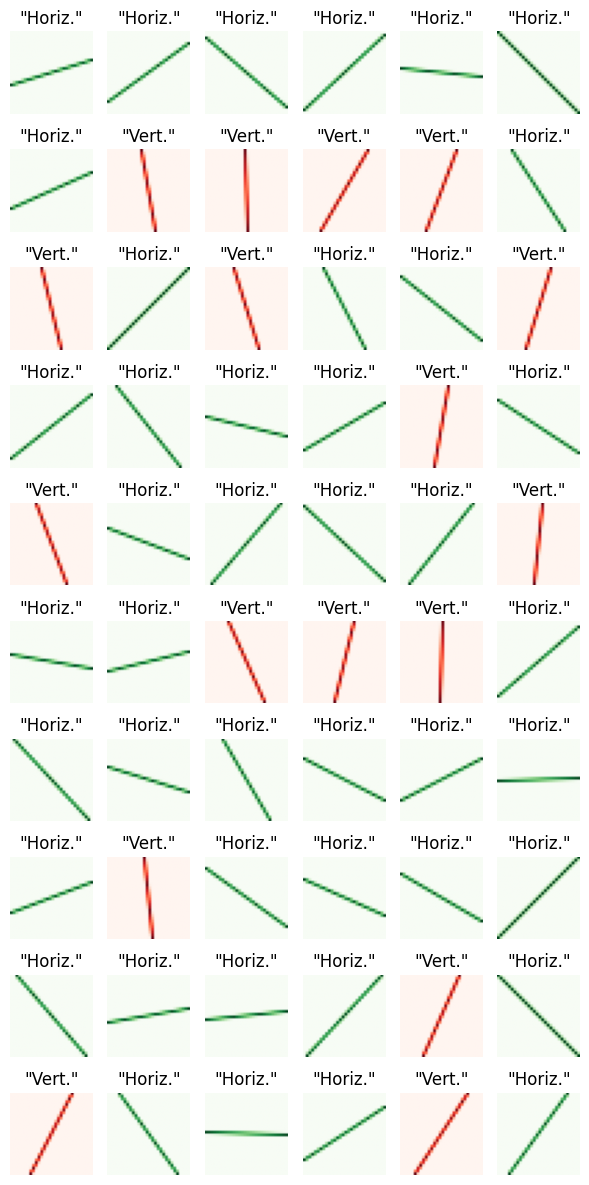

In [33]:
# The same predictions as pictures, coloured by the model's answer. Scan for
# where red turns to green - that is the boundary, seen directly.

fig,ax = plt.subplots(10,6,figsize=(6,12))

for i,a in enumerate(ax.flatten()):

  if yHat[i]>.5:
    a.imshow(imgs[ridx[i],0,:,:],origin='lower',cmap='Reds')
  else:
    a.imshow(imgs[ridx[i],0,:,:],origin='lower',cmap='Greens')

  # and the title
  title = '"Vert."' if yHat[i].detach()>.5 else '"Horiz."'
  a.set_title(title)
  a.axis('off')

plt.tight_layout()
plt.show()
